In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
from openai import OpenAI
import random
import pickle
import json

In [2]:
load_dotenv(override=True)
os.environ["OPENAI_API_KEY"] = os.getenv('OPENAI_API_KEY')
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
hf_token = os.getenv("HF_TOKEN")
login(hf_token, add_to_git_credential=True)
openai = OpenAI()


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
from items import Item
from testing import Tester

In [4]:
%matplotlib inline

In [5]:
with open('train.pkl', 'rb') as file:
    train = pickle.load(file=file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file=file)

In [6]:
train_fine_tune = train[:500]
validation_fine_tune = train[500:550]

In [7]:
wandb_integration = {"type": "wandb", "wandb": {"project": "gpt-pricer"}}

In [8]:
def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [9]:
def make_jsonl(items):
    result = ""
    for item in items:
        message = messages_for(item)
        message_str = json.dumps(message)
        result += '{"messages": ' +  message_str + '}\n'
    return result.strip()

In [10]:
print(make_jsonl(train[:3]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\nDelphi FG0166 Fuel Pump Module\nDelphi brings 80 years of OE Heritage into each Delphi pump, ensuring quality and fitment for each Delphi part. Part is validated, tested and matched to the right vehicle application Delphi brings 80 years of OE Heritage into each Delphi assembly, ensuring quality and fitment for each Delphi part Always be sure to check and clean fuel tank to avoid unnecessary returns Rigorous OE-testing ensures the pump can withstand extreme temperatures Brand Delphi, Fit Type Vehicle Specific Fit, Dimensions LxWxH 19.7 x 7.7 x 5.1 inches, Weight 2.2 Pounds, Auto Part Position Unknown, Operation Mode Mechanical, Manufacturer Delphi, Model FUEL PUMP, Dimensions 19.7"}, {"role": "assistant", "content": "Price is $226.95"}]}
{"messages": [{"role": "system", "content": "You estimate prices of items. 

In [11]:
def write_jsonl(items, filename):
    with open(filename, 'w') as f:
        jsonl_file = make_jsonl(items)
        f.write(jsonl_file)

In [12]:
write_jsonl(train_fine_tune, 'fine_tune_train.jsonl')

In [13]:
write_jsonl(validation_fine_tune, 'fine_tune_validation.jsonl')

In [14]:
with open('fine_tune_train.jsonl', 'rb') as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [15]:
with open('fine_tune_validation.jsonl', 'rb') as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [16]:
validation_file

FileObject(id='file-LN1gGmf9xYk3p89rXMskNL', bytes=47059, created_at=1762701806, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [17]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model='gpt-4.1-mini-2025-04-14',
    seed=42,
    hyperparameters={"n_epochs": 1},
    integrations=[wandb_integration],
    suffix='pricer',
)

FineTuningJob(id='ftjob-vym1MqasGAWeZC2FGzJ4NME1', created_at=1762701815, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4.1-mini-2025-04-14', object='fine_tuning.job', organization_id='org-PwbEgl7hLswmei0amEMrqbLi', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-DMHtvEZKkCBLLo7PN5duuu', validation_file='file-LN1gGmf9xYk3p89rXMskNL', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-vym1MqasGAWeZC2FGzJ4NME1'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pric

In [18]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [19]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-vym1MqasGAWeZC2FGzJ4NME1', created_at=1762701815, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4.1-mini-2025-04-14', object='fine_tuning.job', organization_id='org-PwbEgl7hLswmei0amEMrqbLi', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-DMHtvEZKkCBLLo7PN5duuu', validation_file='file-LN1gGmf9xYk3p89rXMskNL', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-vym1MqasGAWeZC2FGzJ4NME1'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pric

In [21]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=20).data

[FineTuningJobEvent(id='ftevent-wNUBmkmxwHVSS3v5P3O3orcF', created_at=1762701988, level='info', message='Fine-tuning job started', object='fine_tuning.job.event', data=None, type='message'),
 FineTuningJobEvent(id='ftevent-CIXhPtpHqelSmoyhFX2RuuoP', created_at=1762701984, level='info', message='Files validated, moving job to queued state', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-ZKv1QpEUrZeFLbm2OzIDPER7', created_at=1762701815, level='info', message='Validating training file: file-DMHtvEZKkCBLLo7PN5duuu and validation file: file-LN1gGmf9xYk3p89rXMskNL', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-WNDh6FdZTYnfH9VZxobp37fR', created_at=1762701815, level='info', message='Created fine-tuning job: ftjob-vym1MqasGAWeZC2FGzJ4NME1', object='fine_tuning.job.event', data={}, type='message')]

In [22]:
job_id = 'ftjob-CadpAbwwVhWUU8C02FYHJr14'

In [23]:
import wandb
from wandb.integration.openai.fine_tuning import WandbLogger

# Log in to Weights & Biases.
wandb.login()
# Sync the fine-tuning job with Weights & Biases.
WandbLogger.sync(fine_tune_job_id=job_id, project="pricer")

wandb: Currently logged in as: soroushav85 (soroushav85-soroushav) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Retrieving fine-tune job...


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/
wandb: Waiting for the OpenAI fine-tuning job to finish training...
wandb: To avoid blocking, you can call `WandbLogger.sync` with `wait_for_job_success=False` after OpenAI training completes.
wandb: Fine-tuning finished, logging metrics, model metadata, and run metadata to Weights & Biases
wandb: Logging training/validation files...


train_accuracy,▁▅▅▅█▅█▅▅▅██▅▅▅▅█▅▅▅█▅▅█▅█▅█▅▅█▅▅▅█▅█▅█▅
train_loss,█▆▁▃▃▃▃▄▁▃▂▃▁▂▁▄▂▁▃▄▃▃▂▃▂▂▁▃▃▃▄▄▃▃▃▃▃▂▁▂
valid_loss,█▅▂▇▅▆▇▆▁▅█▂▅▇▆▆▂▇█▆█▃▇▆▄▆▆▆▁▆▇▅▂▆▇▃▅█▃▇
valid_mean_token_accuracy,▁▅█▅▅▅▅██▅▅█▅▅▅▅█▅▅██▅█▅██▅▅▅██▅▅█▅▅█▅▅▅
fine_tuned_model,ft:gpt-4.1-mini-2025...
status,succeeded
train_accuracy,0.75
train_loss,1.1334
valid_loss,1.62842
valid_mean_token_accuracy,0.75


'🎉 wandb sync completed successfully'

In [26]:
model_fine_tuned = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model


In [49]:
def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [29]:
import re
def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [30]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [31]:
def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=model_fine_tuned,
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [33]:
print(test[10].price)
gpt_fine_tuned(test[10])

254.21


179.99

1: Guess: $194.47 Truth: $374.41 Error: $179.94 SLE: 0.43 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $156.66 Truth: $225.11 Error: $68.45 SLE: 0.13 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $83.57 Truth: $61.68 Error: $21.89 SLE: 0.09 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $490.00 Truth: $599.99 Error: $109.99 SLE: 0.04 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $10.99 Truth: $16.99 Error: $6.00 SLE: 0.16 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $32.99 Truth: $31.99 Error: $1.00 SLE: 0.00 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $174.99 Truth: $101.79 Error: $73.20 SLE: 0.29 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $367.99 Truth: $289.00 Error: $78.99 SLE: 0.06 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $599.00 Truth: $635.86 Error: $36.86 SLE: 0.00 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $110.47 Truth: $65.99 Error: $44.48 SLE: 0.26 I

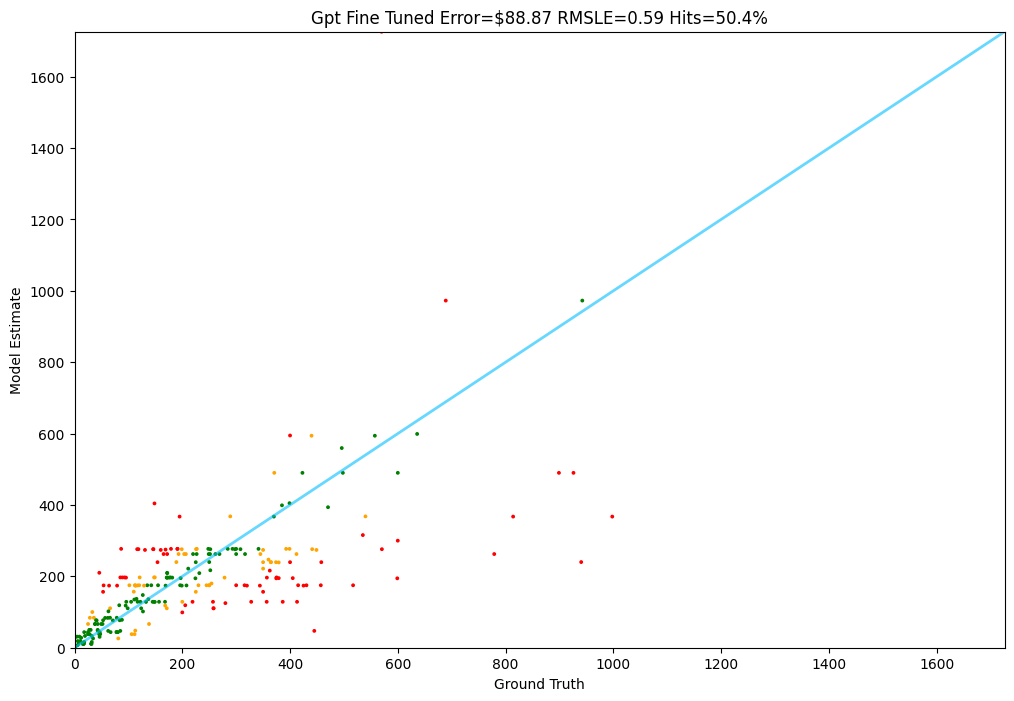

In [34]:
Tester.test(gpt_fine_tuned, test)

## Second try

In [35]:
def messages_for(item):
    system_message = "You estimate prices of items of an e-commerce  based on its attributes, try guessing the most reasonable price. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [36]:
train_fine_tune_2 = train[600:1100]
validation_fine_tune_2 = train[1100:1150]

In [37]:
write_jsonl(train_fine_tune_2, 'fine_tune_train_2.jsonl')

In [38]:
write_jsonl(validation_fine_tune_2, 'fine_tune_validation_2.jsonl')

In [39]:
with open('fine_tune_train_2.jsonl', 'rb') as file:
    train_file = openai.files.create(file=file, purpose='fine-tune')

In [41]:
with open('fine_tune_validation_2.jsonl', 'rb') as file:
    validation_file = openai.files.create(file=file, purpose='fine-tune')

In [42]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model='gpt-4.1-mini-2025-04-14',
    hyperparameters={'n_epochs': 2},
    seed=42,
    integrations=[wandb_integration],
    suffix='pricer'
)

FineTuningJob(id='ftjob-84kfBEYEKUz0E1MfW6MomGkD', created_at=1762705274, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=2), model='gpt-4.1-mini-2025-04-14', object='fine_tuning.job', organization_id='org-PwbEgl7hLswmei0amEMrqbLi', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-M54yFewEJAzVyoS7mZfXLQ', validation_file='file-JDViwbWb47HRE3ZsDekcmR', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-84kfBEYEKUz0E1MfW6MomGkD'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=2))), user_provided_suffix='pric

In [43]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id
job_id

'ftjob-84kfBEYEKUz0E1MfW6MomGkD'

In [47]:
model_fine_tuned = openai.fine_tuning.jobs.retrieve(fine_tuning_job_id=job_id).fine_tuned_model
model_fine_tuned

'ft:gpt-4.1-mini-2025-04-14:dixton:pricer:Ca2r3Z47'

In [50]:
def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=model_fine_tuned,
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

1: Guess: $194.47 Truth: $374.41 Error: $179.94 SLE: 0.43 Item: OEM AC Compressor w/A/C Repair Kit For F...
2: Guess: $156.66 Truth: $225.11 Error: $68.45 SLE: 0.13 Item: Motorcraft YB3125 Fan Clutch
3: Guess: $174.57 Truth: $61.68 Error: $112.89 SLE: 1.06 Item: Dorman 603-159 Front Washer Fluid Reserv...
4: Guess: $649.00 Truth: $599.99 Error: $49.01 SLE: 0.01 Item: HP Premium 17.3-inch HD Plus Touchscreen...
5: Guess: $10.99 Truth: $16.99 Error: $6.00 SLE: 0.16 Item: 5-Position Super Switch Pickup Selector ...
6: Guess: $32.99 Truth: $31.99 Error: $1.00 SLE: 0.00 Item: Horror Bookmarks, Resin Horror Bookmarks...
7: Guess: $174.95 Truth: $101.79 Error: $73.16 SLE: 0.29 Item: SK6241 - Stinger 4 Gauge 6000 Series Pow...
8: Guess: $299.00 Truth: $289.00 Error: $10.00 SLE: 0.00 Item: Godox ML60Bi LED Light Kit, Handheld LED...
9: Guess: $239.99 Truth: $635.86 Error: $395.87 SLE: 0.94 Item: Randall RG75DG3PLUS G3 Plus 100-Watt Com...
10: Guess: $66.47 Truth: $65.99 Error: $0.48 SLE: 0.00 I

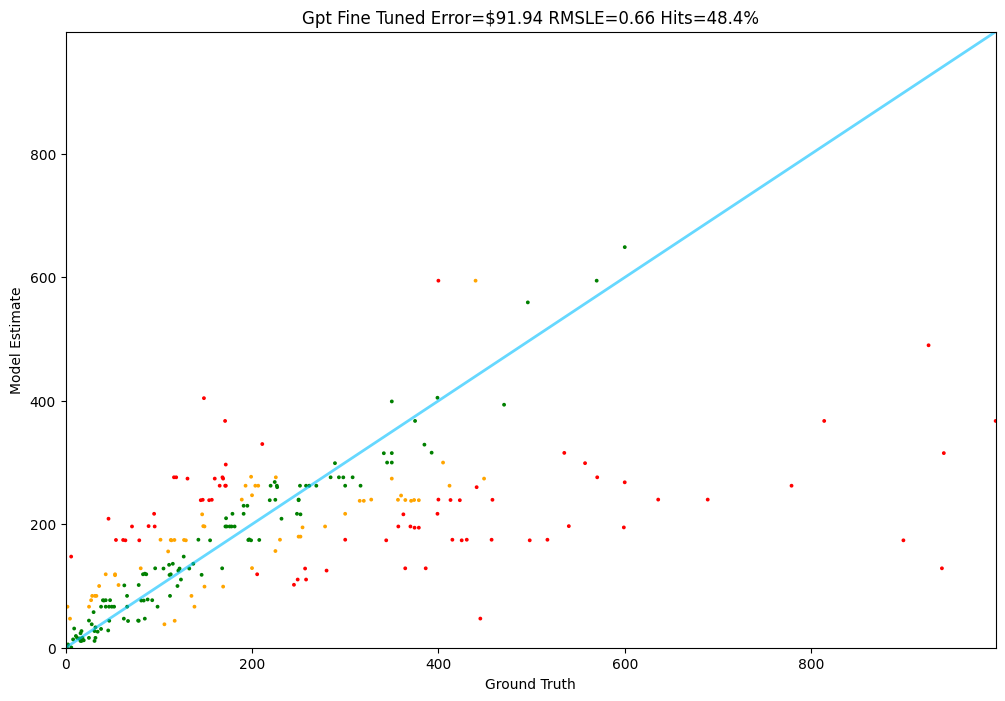

In [51]:
Tester.test(gpt_fine_tuned, test)